# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller

In [3]:
from itertools import product
from tqdm.notebook import tqdm
from typing import Union

# Exercise 1

In [4]:
np.random.seed(42)
arma = ArmaProcess(ar=(1, -0.33), ma=(1, 0.9)).generate_sample(nsample=1000)

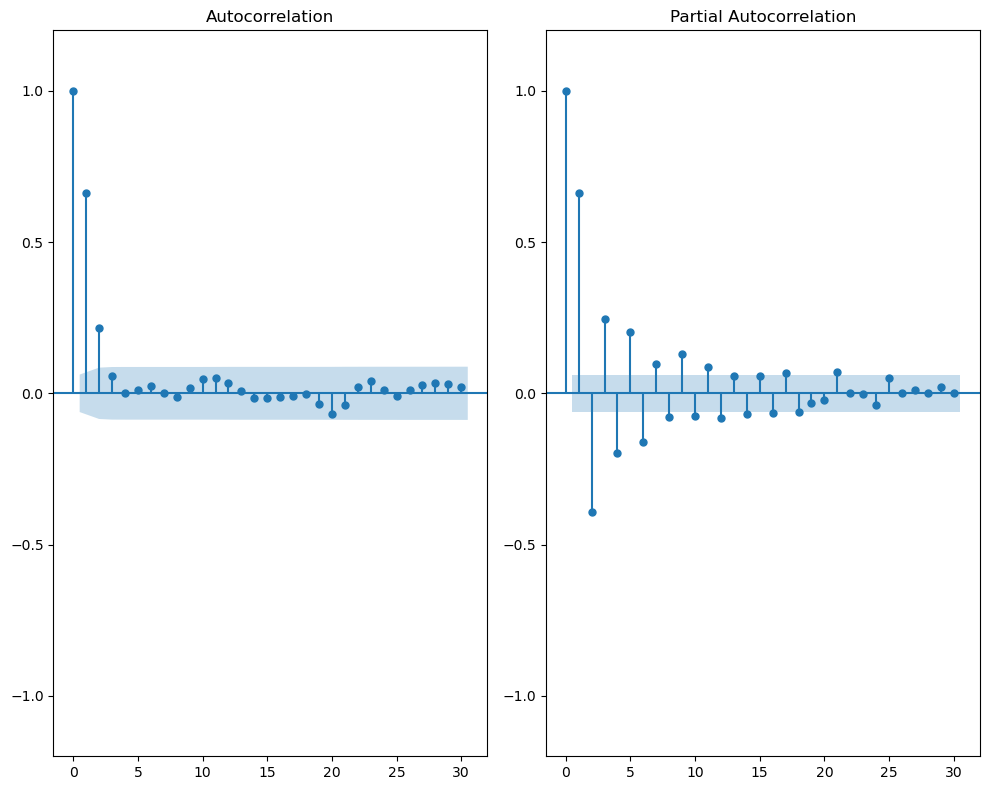

In [5]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
plot_acf(arma, ax=ax1)
ax1.set_ylim([-1.2, 1.2])
plot_pacf(arma, ax=ax2)
ax2.set_ylim([-1.2, 1.2])
fig.tight_layout()
plt.show()

In [6]:
def optimize_AIC(series: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    """
    Compute AIC for each pair of (p, q) on order_list.

    Params:
    -------
    series: Unin[pd.Series, list]
        Univariate time series
    order_list: list
        list with bidimensional tuples with (p, q)

    Returns:
    -------
        A dataframe with three columns: p, q, and AIC.
    """
    p = []
    q = []
    aic =[]

    for order in tqdm(order_list):
        try:
            model = SARIMAX(series, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
        p.append(order[0])
        q.append(order[1])
        aic.append(model.aic)

    return pd.DataFrame({
        'p': p, 'q': q, 'aic': aic
    }).sort_values(by='aic', ascending=True).reset_index(drop=True)
        

In [7]:
?optimize_AIC

Signature: optimize_AIC(series: pandas.Series | list, order_list: list) -> pandas.DataFrame
Docstring:
Compute AIC for each pair of (p, q) on order_list.

Params:
-------
series: Unin[pd.Series, list]
    Univariate time series
order_list: list
    list with bidimensional tuples with (p, q)

Returns:
-------
    A dataframe with three columns: p, q, and AIC.
File:      /tmp/ipykernel_15650/3629937155.py
Type:      function

In [8]:
optimize_AIC(
    list(arma),
    list(product(np.arange(4), np.arange(4)))
)

  0%|          | 0/16 [00:00<?, ?it/s]

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,q,aic
0,1,1,2801.407785
1,2,1,2802.906070
2,1,2,2802.967762
3,0,3,2803.666793
4,1,3,2804.524027
5,3,1,2804.588567
6,2,2,2804.822282
7,3,3,2806.026102
8,2,3,2806.175380
9,3,2,2806.894930


In [9]:
train = arma[:800]

In [10]:
test = arma[800:]

In [11]:
def rolling_forecast(series: Union[pd.Series, list], train_len: int, horizon: int, window: int, method: str,
                    order: Union[list, tuple] = [2, 0, 2]) -> list:
    """
    Rolling forecast for ARMA(2,2) model.

    Two baseline models are also implemented to comparison: last value and mean.

    Params:
    -------
    series: pd.Series
        Series object with the time series to be predicted.
    train_len: int
        train size
    horizon: int
        how many steps ahead to be predicted
    window: int
        how many steps ahead to be predicted at each iteration
    method: str
        prediction method. It must be one of "mean", "last", "arma".
    order: Union[list, tuple]
        order of ARMA model. Defaults to (2, 0, 2).

    Returns:
    --------
        returns a list of predicted values
    """

    if method not in ['mean', 'last', 'arma']:
        raise ValueError("'method' must be one of ['mean', 'last', 'arma']")

    total_len = train_len + horizon

    # ensure the time_series is a numpy array
    time_series = np.array(series)

    if method == 'mean':
        pred_mean = []

        for i in tqdm(range(train_len, total_len, window), desc='mean'):
            media = np.mean(time_series[:i])
            pred_mean.extend([media for _ in range(window)])
        
        return pred_mean
    elif method == 'last':
        pred_last = []
        
        for i in tqdm(range(train_len, total_len, window), desc='last'):
            last_value = time_series[i-1]
            pred_last.extend([last_value for _ in range(window)])
        
        return pred_last
    elif method == 'arma':
        pred_arma = []

        for i in tqdm(range(train_len, total_len, window), desc='ARMA'):
            model = SARIMAX(time_series, order=order)
            model_fit = model.fit(disp=False)
            predictions = model_fit.get_prediction(0, i + window - 1)
            oos_predictions = predictions.predicted_mean[-window:]
            pred_arma.extend(oos_predictions)
        
        return pred_arma

In [12]:
?rolling_forecast

Signature:
rolling_forecast(
    series: pandas.Series | list,
    train_len: int,
    horizon: int,
    window: int,
    method: str,
    order: list | tuple = [2, 0, 2],
) -> list
Docstring:
Rolling forecast for ARMA(2,2) model.

Two baseline models are also implemented to comparison: last value and mean.

Params:
-------
series: pd.Series
    Series object with the time series to be predicted.
train_len: int
    train size
horizon: int
    how many steps ahead to be predicted
window: int
    how many steps ahead to be predicted at each iteration
method: str
    prediction method. It must be one of "mean", "last", "arma".
order: Union[list, tuple]
    order of ARMA model. Defaults to (2, 0, 2).

Returns:
--------
    returns a list of predicted values
File:      /tmp/ipykernel_15650/3927149539.py
Type:      function

In [13]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 1
order = (1, 0, 1)

In [14]:
pred_arma_101 = pd.DataFrame({
    'actual': test,
    'mean': rolling_forecast(arma, TRAIN_LEN, HORIZON, WINDOW, method='mean', order=order),
    'last': rolling_forecast(arma, TRAIN_LEN, HORIZON, WINDOW, method='last', order=order),
    'arma': rolling_forecast(arma, TRAIN_LEN, HORIZON, WINDOW, method='arma', order=order)
}, index=np.arange(800, 1000, 1))

mean:   0%|          | 0/200 [00:00<?, ?it/s]

last:   0%|          | 0/200 [00:00<?, ?it/s]

ARMA:   0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
performance_arma_101 = pd.Series({
    'mean': mean_squared_error(pred_arma_101['actual'], pred_arma_101['mean']),
    'last': mean_squared_error(pred_arma_101['actual'], pred_arma_101['last']),
    'ARMA(1,1)': mean_squared_error(pred_arma_101['actual'], pred_arma_101['arma']),
})

In [16]:
performance_arma_101

mean         2.679253
last         1.676146
ARMA(1,1)    0.925675
dtype: float64

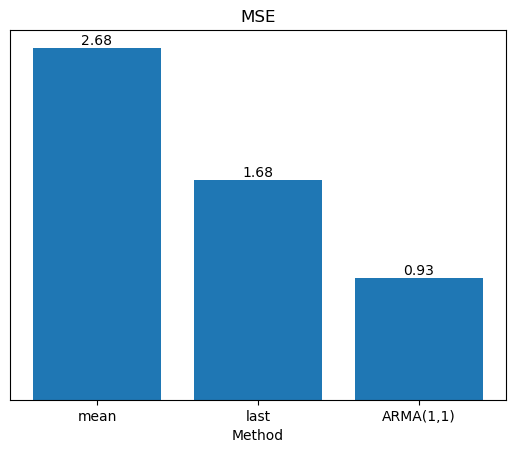

In [17]:
fig, ax = plt.subplots()
bars = ax.bar(performance_arma_101.index, performance_arma_101.values)
ax.bar_label(bars, fmt='%.2f')
ax.set_xlabel('Method')
ax.set_yticks([])
ax.set_title('MSE')
plt.show()

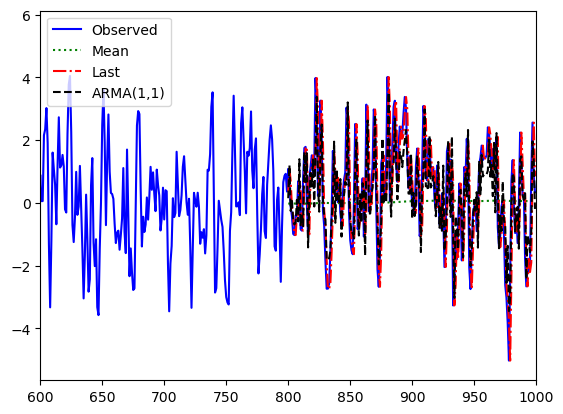

In [18]:
fig, ax = plt.subplots()
ax.plot(pd.Series(arma, index=np.arange(1000)), 'b-', label='Observed')
ax.plot(pred_arma_101['mean'], 'g:', label='Mean')
ax.plot(pred_arma_101['last'], 'r-.', label='Last')
ax.plot(pred_arma_101['arma'], 'k--', label='ARMA(1,1)')
ax.set_xlim([600, 1000])
ax.legend(loc='upper left')
plt.show()

# Modelos AR

## AR(1)

In [19]:
def analisar_arma(ar: Union[tuple, list], ma: Union[tuple, list], size: int = 10_000):
    series = ArmaProcess(ar=ar, ma=ma).generate_sample(nsample=1000)

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
    plot_acf(series, ax=ax[0])
    plot_pacf(series, ax=ax[1])

    fig.tight_layout()
    plt.show()
    return series
    

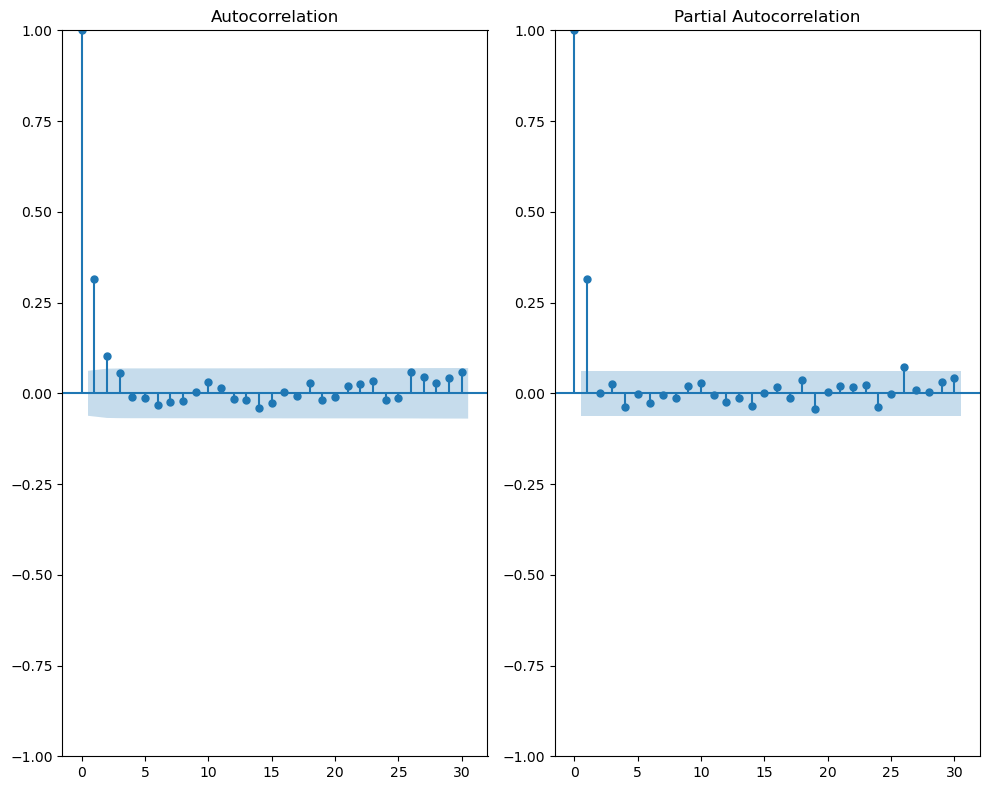

In [20]:
series = analisar_arma(ar=(1, -0.33), ma=(1))

## AR(2)

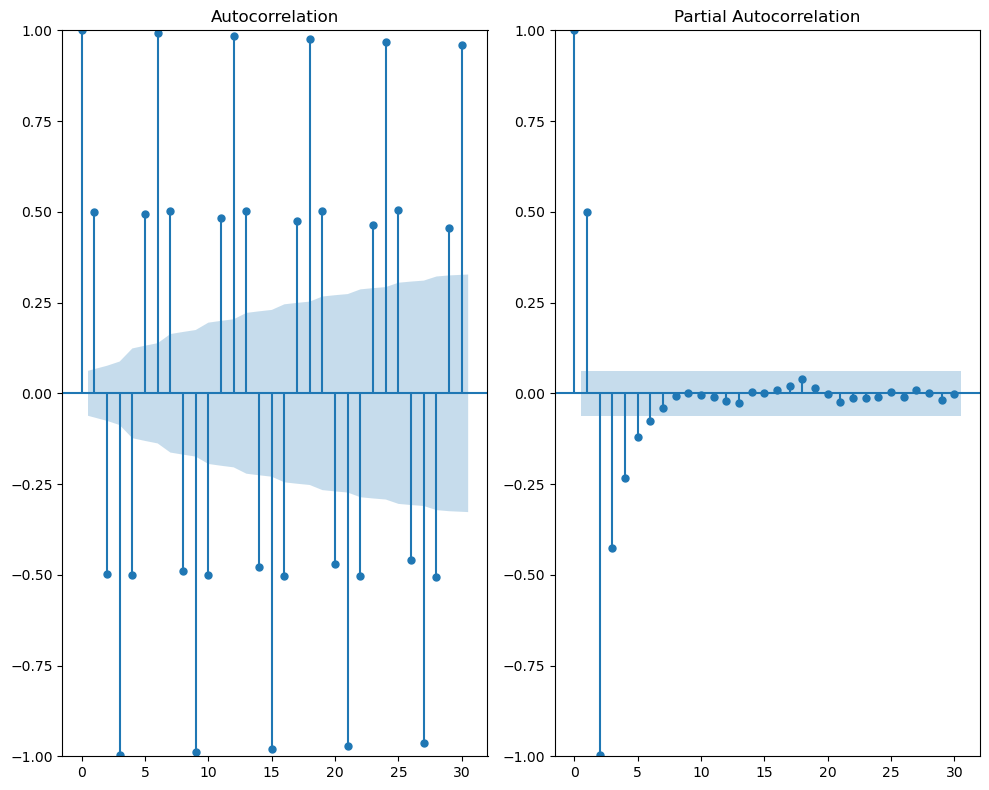

In [21]:
series = analisar_arma(ar=(1, -1, 1), ma=(1))

In [22]:
adfuller(series)

(np.float64(-899.7114936947825),
 0.0,
 1,
 998,
 {'1%': np.float64(-3.4369193380671),
  '5%': np.float64(-2.864440383452517),
  '10%': np.float64(-2.56831430323573)},
 np.float64(2742.052749413274))

## MA(1)

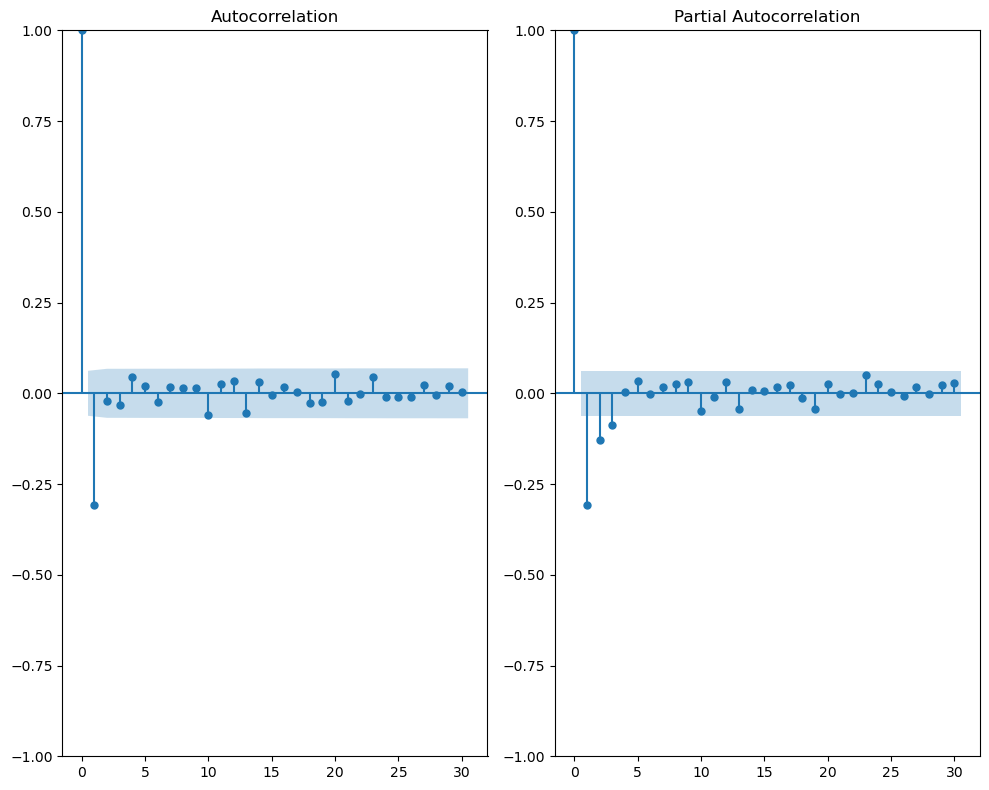

In [23]:
series = analisar_arma(ar=(1), ma=(1, -1/3))

In [24]:
adfuller(series)

(np.float64(-23.33196947880659),
 0.0,
 2,
 997,
 {'1%': np.float64(-3.4369259442540416),
  '5%': np.float64(-2.8644432969122833),
  '10%': np.float64(-2.5683158550174094)},
 np.float64(2819.3109139284416))

## MA(2)

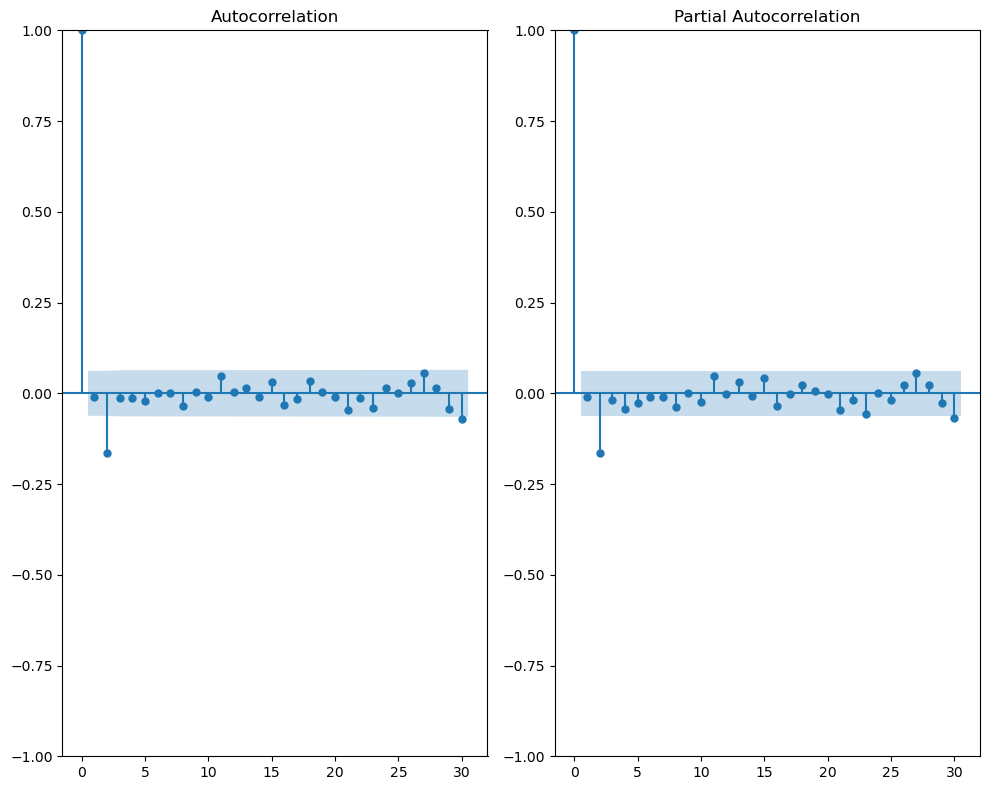

In [25]:
series = analisar_arma(ar=(1), ma=(1, 1.75, -1))

In [26]:
adfuller(series)

(np.float64(-26.472544399402686),
 0.0,
 1,
 998,
 {'1%': np.float64(-3.4369193380671),
  '5%': np.float64(-2.864440383452517),
  '10%': np.float64(-2.56831430323573)},
 np.float64(4304.922985683177))

## Exercise 2

### 1

In [27]:
np.random.seed(42)
ma2 = np.array([1, 0.9, 0.3])
ar2 = np.array([1, -0.33, -0.5])
arma_202 = ArmaProcess(ar=ar2, ma=ma2).generate_sample(nsample=1_000)

### 2

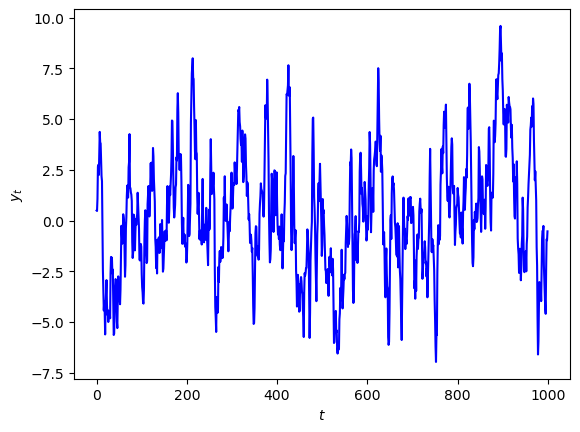

In [28]:
fig, ax = plt.subplots()
ax.plot(arma_202, 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.show()

### 3

In [29]:
adfuller(arma_202)

(np.float64(-6.54560167062495),
 np.float64(9.116103820932454e-09),
 3,
 996,
 {'1%': np.float64(-3.4369325637409154),
  '5%': np.float64(-2.8644462162311934),
  '10%': np.float64(-2.568317409920808)},
 np.float64(2738.2598932171895))

### 4

In [30]:
df = pd.DataFrame(arma_202)

In [31]:
train = df.loc[:800]

In [32]:
test = df.loc[800:]

### 5

In [33]:
order = list(product(np.arange(5), np.arange(5)))
order

[(np.int64(0), np.int64(0)),
 (np.int64(0), np.int64(1)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(0), np.int64(4)),
 (np.int64(1), np.int64(0)),
 (np.int64(1), np.int64(1)),
 (np.int64(1), np.int64(2)),
 (np.int64(1), np.int64(3)),
 (np.int64(1), np.int64(4)),
 (np.int64(2), np.int64(0)),
 (np.int64(2), np.int64(1)),
 (np.int64(2), np.int64(2)),
 (np.int64(2), np.int64(3)),
 (np.int64(2), np.int64(4)),
 (np.int64(3), np.int64(0)),
 (np.int64(3), np.int64(1)),
 (np.int64(3), np.int64(2)),
 (np.int64(3), np.int64(3)),
 (np.int64(3), np.int64(4)),
 (np.int64(4), np.int64(0)),
 (np.int64(4), np.int64(1)),
 (np.int64(4), np.int64(2)),
 (np.int64(4), np.int64(3)),
 (np.int64(4), np.int64(4))]

### 6

In [34]:
?optimize_AIC

Signature: optimize_AIC(series: pandas.Series | list, order_list: list) -> pandas.DataFrame
Docstring:
Compute AIC for each pair of (p, q) on order_list.

Params:
-------
series: Unin[pd.Series, list]
    Univariate time series
order_list: list
    list with bidimensional tuples with (p, q)

Returns:
-------
    A dataframe with three columns: p, q, and AIC.
File:      /tmp/ipykernel_15650/3629937155.py
Type:      function

In [35]:
optimize_AIC(arma_202, order)

  0%|          | 0/25 [00:00<?, ?it/s]

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("M

,p,q,aic
0,1,2,2802.955742
1,4,0,2803.318659
2,1,3,2803.732386
3,2,2,2803.944603
4,4,1,2805.015389
5,2,3,2805.298550
6,3,2,2805.298671
7,2,0,2805.422265
8,1,4,2805.517786
9,3,4,2806.195180


### 6

In [36]:
p, q = 2, 2

### 7

In [37]:
model = SARIMAX(arma_202, order=(p, 0, q))

In [38]:
model_fit = model.fit(disp=False)

In [39]:
residuals = model_fit.resid

In [47]:
residuals[:10]

array([ 0.49671415,  0.00703023,  0.64963683,  1.48250088, -0.18332603,
       -0.28022317,  1.56996888,  0.82348725, -0.49749806,  0.50926953])

### 8

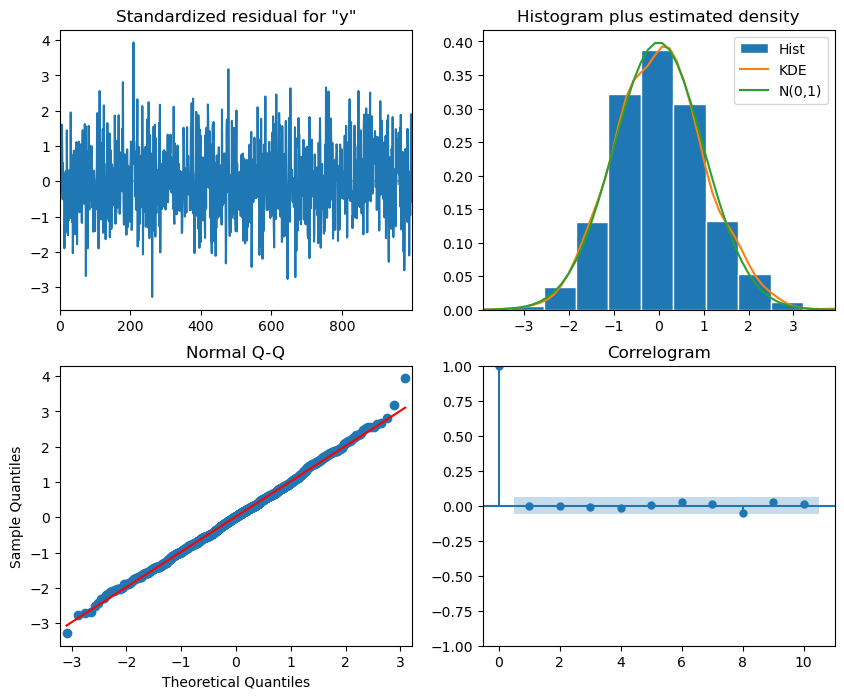

In [41]:
model_fit.plot_diagnostics(figsize=(10, 8));

### 9

In [46]:
acorr_ljungbox(residuals, lags=10)

,lb_stat,lb_pvalue
1,0.000130,0.990887
2,0.009043,0.995489
3,0.142435,0.986299
4,0.454605,0.977767
5,0.464865,0.993353
6,1.326858,0.970156
7,1.418360,0.985002
8,3.849627,0.870429
9,4.689488,0.860493
10,4.919935,0.896462


### 10

In [42]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2
order = (p, 0, q)

In [43]:
?rolling_forecast

Signature:
rolling_forecast(
    series: pandas.Series | list,
    train_len: int,
    horizon: int,
    window: int,
    method: str,
    order: list | tuple = [2, 0, 2],
) -> list
Docstring:
Rolling forecast for ARMA(2,2) model.

Two baseline models are also implemented to comparison: last value and mean.

Params:
-------
series: pd.Series
    Series object with the time series to be predicted.
train_len: int
    train size
horizon: int
    how many steps ahead to be predicted
window: int
    how many steps ahead to be predicted at each iteration
method: str
    prediction method. It must be one of "mean", "last", "arma".
order: Union[list, tuple]
    order of ARMA model. Defaults to (2, 0, 2).

Returns:
--------
    returns a list of predicted values
File:      /tmp/ipykernel_15650/3927149539.py
Type:      function

In [48]:
pred = pd.DataFrame({
    'observed': test.values.ravel(),
    'mean': rolling_forecast(arma_202, TRAIN_LEN, HORIZON, WINDOW, method='mean', order=order),
    'last': rolling_forecast(arma_202, TRAIN_LEN, HORIZON, WINDOW, method='last', order=order),
    'arma': rolling_forecast(arma_202, TRAIN_LEN, HORIZON, WINDOW, method='arma', order=order),
}, index=test.index)

mean:   0%|          | 0/100 [00:00<?, ?it/s]

last:   0%|          | 0/100 [00:00<?, ?it/s]

ARMA:   0%|          | 0/100 [00:00<?, ?it/s]

### 11

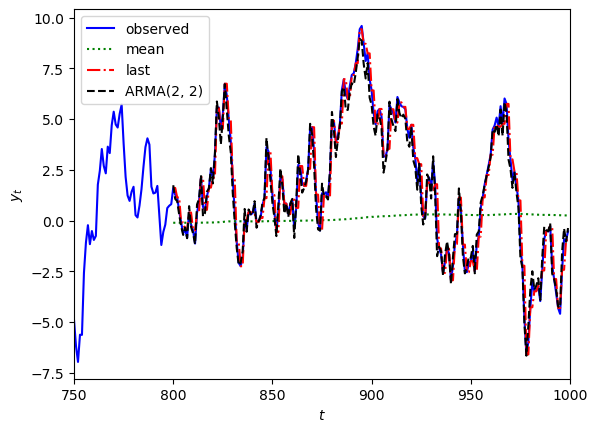

In [54]:
fig, ax = plt.subplots()
ax.plot(df, 'b-', label='observed')
ax.plot(pred['mean'], 'g:', label='mean')
ax.plot(pred['last'], 'r-.', label='last')
ax.plot(pred['arma'], 'k--', label='ARMA(2, 2)')
ax.legend(loc='upper left')
ax.set_xlim([750, 1000])
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.show()

### 13

In [55]:
performance = pd.Series({
    'mean': mean_squared_error(pred['observed'], pred['mean']),
    'last': mean_squared_error(pred['observed'], pred['last']),
    'arma': mean_squared_error(pred['observed'], pred['arma']),
})

In [56]:
performance

mean    12.939204
last     0.558560
arma     0.158821
dtype: float64

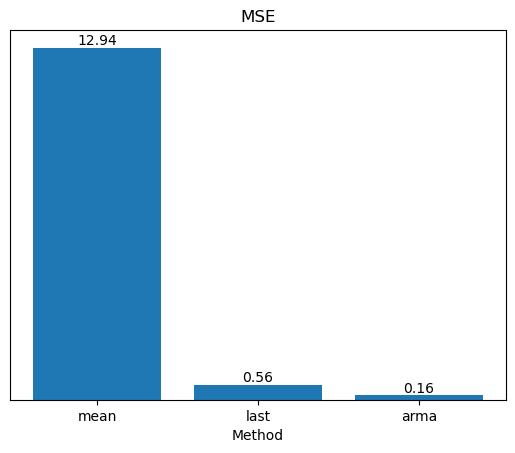

In [60]:
fig, ax = plt.subplots()
bars = ax.bar(performance.index, performance.values)
ax.bar_label(bars, fmt='%.2f')
ax.set_xlabel('Method')
ax.set_yticks([])
ax.set_title('MSE')
plt.show()